In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn librosa


In [2]:
!wget -q "https://raw.githubusercontent.com/primaryobjects/voice-gender/master/voice.csv" -O voice.csv
print("Downloaded!")

Downloaded!


In [3]:
import pandas as pd

df = pd.read_csv("voice.csv")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify shuffle worked
print(df['label'].head(10))
print("Shape:", df.shape)        # how many rows and columns
print("\nFirst 5 rows:")
df.head()

0    female
1      male
2      male
3    female
4    female
5    female
6      male
7      male
8    female
9      male
Name: label, dtype: object
Shape: (3168, 21)

First 5 rows:


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.186833,0.027472,0.184325,0.173955,0.204731,0.030777,2.655225,10.565846,0.821812,0.159883,...,0.186833,0.172790,0.023495,0.271186,0.178571,0.007812,0.226562,0.218750,0.108929,female
1,0.188879,0.060316,0.195537,0.138072,0.242975,0.104904,1.497393,5.037085,0.909425,0.374225,...,0.188879,0.133092,0.050847,0.272727,0.855938,0.023438,8.718750,8.695312,0.098712,male
2,0.150705,0.087127,0.174299,0.069666,0.226082,0.156416,2.603951,22.328899,0.969287,0.781729,...,0.150705,0.109992,0.017260,0.266667,1.240954,0.007812,5.562500,5.554688,0.332396,male
3,0.183667,0.040607,0.182534,0.156480,0.207646,0.051166,2.054138,7.483019,0.898138,0.313925,...,0.183667,0.149237,0.018648,0.262295,0.550312,0.007812,3.421875,3.414062,0.166503,female
4,0.205159,0.039543,0.210805,0.186667,0.228908,0.042241,2.099683,7.562209,0.876002,0.271880,...,0.205159,0.154736,0.047105,0.277457,1.578835,0.187500,10.804688,10.617188,0.113644,female


In [4]:
print(df['label'].value_counts())
print("\nAny missing values?")
print(df.isnull().sum().sum())  # should be 0
print("\nData types:")
print(df.dtypes)

label
female    1584
male      1584
Name: count, dtype: int64

Any missing values?
0

Data types:
meanfreq    float64
sd          float64
median      float64
Q25         float64
Q75         float64
IQR         float64
skew        float64
kurt        float64
sp.ent      float64
sfm         float64
mode        float64
centroid    float64
meanfun     float64
minfun      float64
maxfun      float64
meandom     float64
mindom      float64
maxdom      float64
dfrange     float64
modindx     float64
label        object
dtype: object


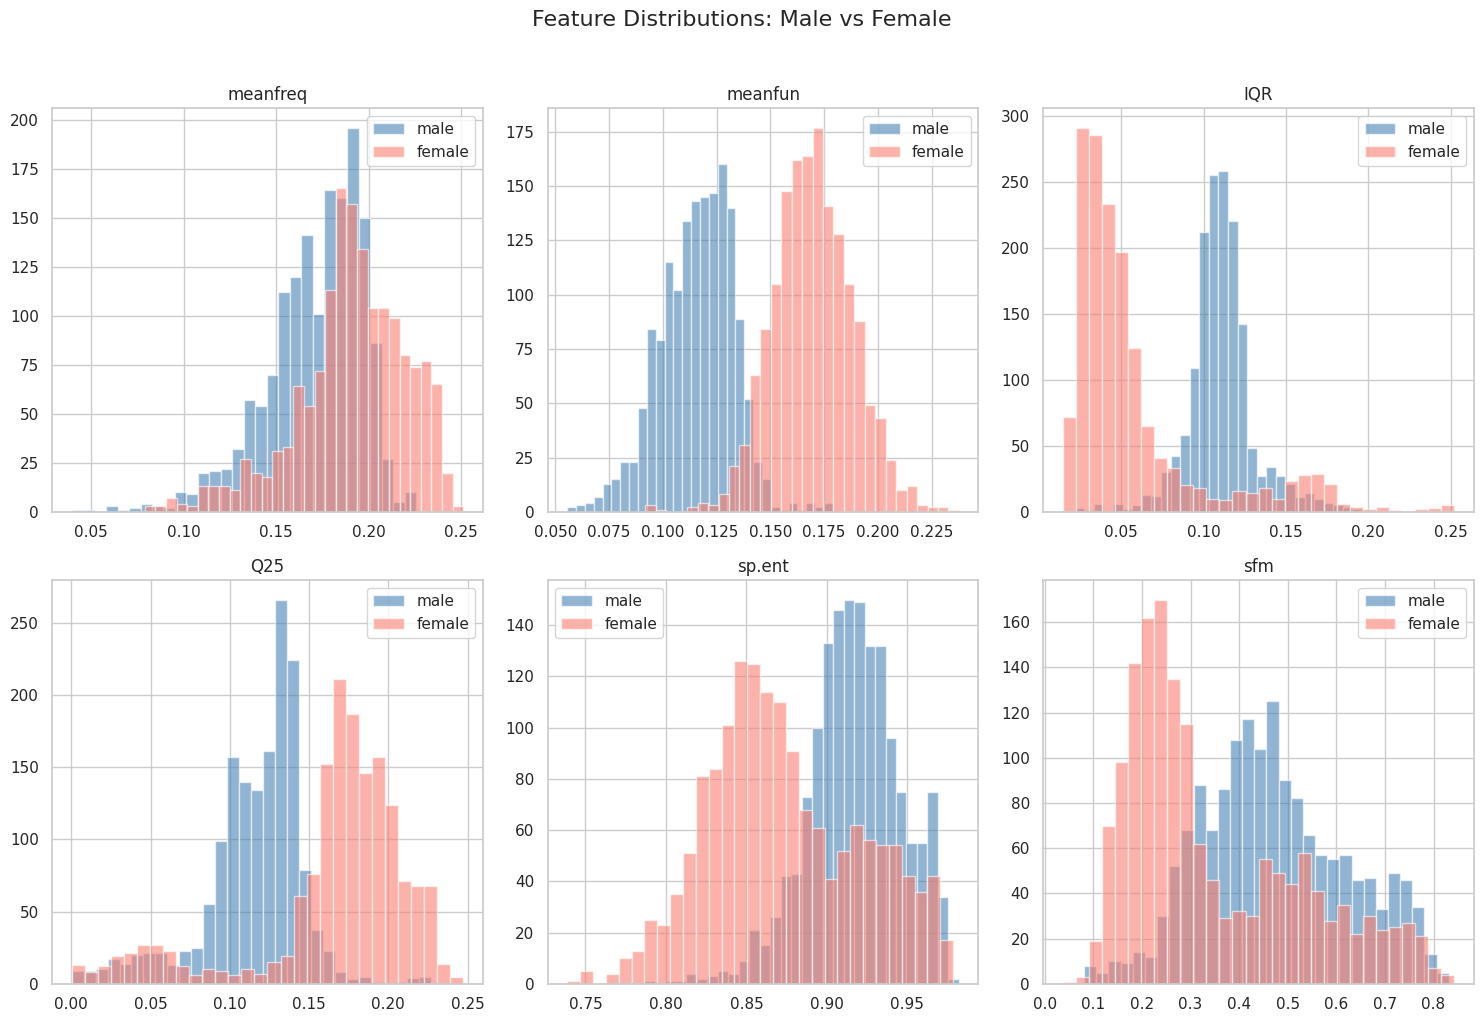

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 6 of the most important features split by gender
features = ['meanfreq', 'meanfun', 'IQR', 'Q25', 'sp.ent', 'sfm']
labels = ['male', 'female']
colors = ['steelblue', 'salmon']

for ax, feature in zip(axes.flatten(), features):
    for label, color in zip(labels, colors):
        subset = df[df['label'] == label][feature]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=label)
    ax.set_title(feature)
    ax.legend()

plt.suptitle("Feature Distributions: Male vs Female", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) from label (y)
X = df.drop('label', axis=1)          # everything except label
y = df['label'].map({'male': 0, 'female': 1})  # convert text to 0/1

# 2. Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Standardize (scale all features to same range)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)#
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features:", X_train.shape[1])

Training samples: 2534
Testing samples: 634
Features: 20


Accuracy: 0.9763406940063092

Detailed Report:
              precision    recall  f1-score   support

        male       0.97      0.98      0.98       324
      female       0.98      0.97      0.98       310

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



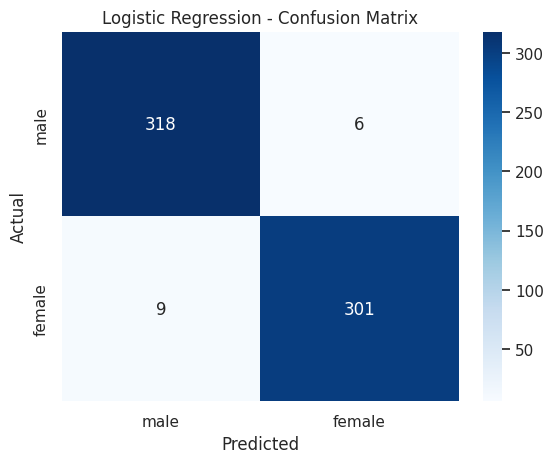

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train the model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predict on test set
y_pred = lr.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['male', 'female']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['male','female'],
            yticklabels=['male','female'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Logistic Regression: 0.9763
Gaussian NB: 0.8880
Bernoulli NB: 0.8738
Linear SVM: 0.9795


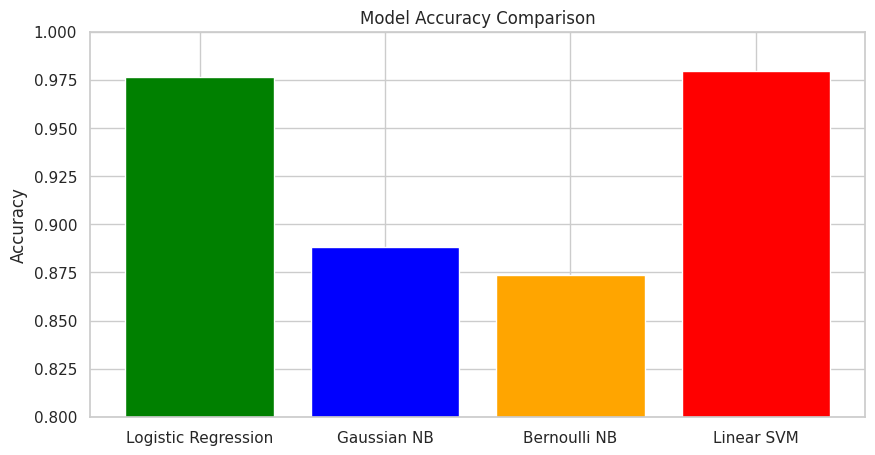

In [8]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import SVC

# All 4 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Gaussian NB':         GaussianNB(),
    'Bernoulli NB':        BernoulliNB(),
    'Linear SVM':          SVC(kernel='linear')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

# Bar chart comparison
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color=['green','blue','orange','red'])
plt.ylim(0.8, 1.0)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [9]:
print(df['label'].head(10))  # first 10
print(df['label'].tail(10))  # last 10

0    female
1      male
2      male
3    female
4    female
5    female
6      male
7      male
8    female
9      male
Name: label, dtype: object
3158      male
3159      male
3160      male
3161    female
3162    female
3163    female
3164      male
3165      male
3166      male
3167      male
Name: label, dtype: object


In [10]:
from sklearn.model_selection import StratifiedKFold

# StratifiedKFold shuffles AND ensures each fold
# has balanced male/female ratio
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("10-Fold Stratified Cross Validation Results:")
print("-" * 45)
for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X, y,
                             cv=cv_strategy, scoring='accuracy')
    print(f"{name}")
    print(f"  Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")
    print()

10-Fold Stratified Cross Validation Results:
---------------------------------------------


NameError: name 'pipelines' is not defined

In [2]:
# Download the RAVDESS emotion dataset
!pip install -q kaggle

# We'll use a direct download instead
!wget -q --show-progress \
  "https://github.com/karoldvl/RAVDESS/archive/refs/heads/master.zip" \
  -O ravdess.zip 2>/dev/null || echo "Trying alternative..."

# Simpler approach - use this dataset directly
!pip install -q datasets
from datasets import load_dataset
print("Ready!")

Trying alternative...
Ready!


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ammar24065","key":"b21dbf691abaa096ceed8f15111805b4"}'}

In [4]:
import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
os.rename("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle configured!")

Kaggle configured!


In [5]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
!unzip -q ravdess-emotional-speech-audio.zip -d ravdess
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:04<00:00, 104MB/s]

Dataset ready!


In [6]:
import os

# Let's explore the dataset structure
for root, dirs, files in os.walk("ravdess"):
    level = root.replace("ravdess", "").count(os.sep)
    if level < 2:  # only show top 2 levels
        indent = " " * 2 * level
        print(f"{indent}{os.path.basename(root)}/")

# Count total audio files
wav_files = []
for root, dirs, files in os.walk("ravdess"):
    for file in files:
        if file.endswith(".wav"):
            wav_files.append(os.path.join(root, file))

print(f"\nTotal .wav files: {len(wav_files)}")
print(f"Example filename: {os.path.basename(wav_files[0])}")

ravdess/
  Actor_13/
  Actor_05/
  Actor_18/
  Actor_08/
  Actor_10/
  Actor_01/
  Actor_23/
  Actor_12/
  Actor_24/
  Actor_16/
  Actor_03/
  Actor_14/
  Actor_22/
  Actor_07/
  Actor_15/
  Actor_04/
  Actor_19/
  Actor_20/
  Actor_21/
  Actor_02/
  Actor_11/
  Actor_09/
  Actor_06/
  audio_speech_actors_01-24/
  Actor_17/

Total .wav files: 2880
Example filename: 03-01-04-01-02-01-13.wav


In [13]:
import librosa
import numpy as np
emotion_map={
    '01': 'neutral', '02': 'calm',    '03': 'happy',   '04': 'sad',
    '05': 'angry',   '06': 'fearful', '07': 'disgust',  '08': 'surprised'
}
# 5 emotions now including fearful
target_emotions = {
    '01': 'neutral',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful'
}

# Parse all files
data = []
for filepath in wav_files:
    filename = os.path.basename(filepath)
    parts = filename.split('-')
    emotion_code = parts[2]
    if emotion_code in target_emotions:
        data.append({
            'path': filepath,
            'emotion': target_emotions[emotion_code]
        })

print(f"Total usable files: {len(data)}")
print("\nEmotion distribution:")
from collections import Counter
emotions = [d['emotion'] for d in data]
for emotion, count in Counter(emotions).items():
    print(f"  {emotion}: {count}")

Total usable files: 1728

Emotion distribution:
  sad: 384
  fearful: 384
  neutral: 192
  angry: 384
  happy: 384


In [15]:
import librosa
import numpy as np

def extract_features(filepath):
    # Load the audio file
    audio, sr = librosa.load(filepath, duration=3, offset=0.5)

    # 1. MFCC - captures tone and timbre (most important)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)

    # 2. Chroma - captures pitch class
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)

    # 3. Mel Spectrogram - captures energy distribution
    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_mean = np.mean(mel.T, axis=0)

    # Combine all features into one vector
    return np.concatenate([mfcc_mean, chroma_mean, mel_mean])

# Test on one file
sample = extract_features(data[0]['path'])
print(f"Features extracted: {sample.shape}")
print(f"Emotion: {data[0]['emotion']}")

Features extracted: (180,)
Emotion: sad


In [16]:
from tqdm import tqdm

X = []
y = []

print("Extracting features from all audio files...")
for item in tqdm(data):
    try:
        features = extract_features(item['path'])
        X.append(features)
        y.append(item['emotion'])
    except Exception as e:
        print(f"Skipped {item['path']}: {e}")

X = np.array(X)
print(f"\nDone! Shape: {X.shape}")
print(f"Labels: {len(y)}")

Extracting features from all audio files...


100%|██████████| 1728/1728 [01:45<00:00, 16.38it/s]


Done! Shape: (1728, 180)
Labels: 1728


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Encode labels (convert text to numbers)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Emotion classes:", le.classes_)

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train all 3 models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM':           SVC(kernel='rbf', random_state=42)
}

print("\nResults:")
print("-" * 40)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: {acc:.4f}")

Emotion classes: ['angry' 'fearful' 'happy' 'neutral' 'sad']

Results:
----------------------------------------
Random Forest: 0.9191
Decision Tree: 0.8786
SVM: 0.6358


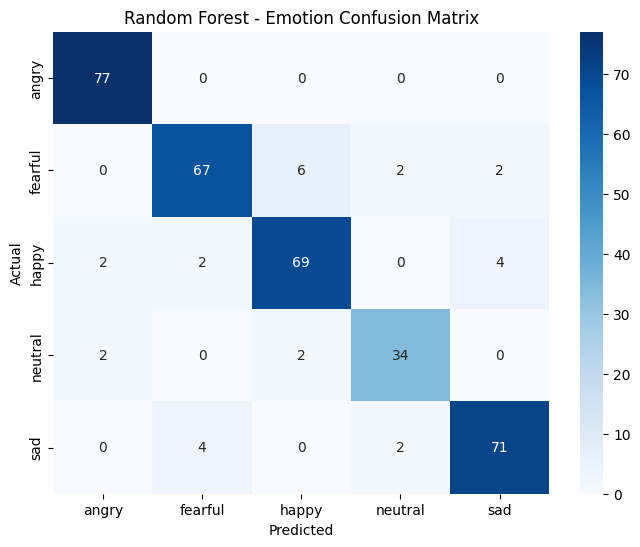


Detailed Report:
              precision    recall  f1-score   support

       angry       0.95      1.00      0.97        77
     fearful       0.92      0.87      0.89        77
       happy       0.90      0.90      0.90        77
     neutral       0.89      0.89      0.89        38
         sad       0.92      0.92      0.92        77

    accuracy                           0.92       346
   macro avg       0.92      0.92      0.92       346
weighted avg       0.92      0.92      0.92       346



In [18]:
# Confusion matrix for best model (Random Forest)
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Emotion Confusion Matrix")
plt.show()

print("\nDetailed Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))